# 1. Install Dependencies and Setup

In [1]:
import tensorflow as tf
import os

In [2]:
# Avoid OOM errors by setting GPU Memory Consumption Growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [3]:
tf.config.list_physical_devices('GPU')

[]

# 2. Remove dodgy images

In [4]:
import cv2
import imghdr

C:\Users\Admin\AppData\Local\Temp\ipykernel_11968\4232469594.py:2: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [5]:
data_dir = 'data' 

In [6]:
image_exts = ('.png', '.jpg', '.jpeg')

In [7]:
for image_class in os.listdir(data_dir): 
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try: 
            img = cv2.imread(image_path)
            if not image_path.lower().endswith(image_exts):
                print('Image not in ext list {}'.format(image_path))
                os.remove(image_path)
            else:
                print('Image valid')
        except Exception as e: 
            print('Issue with image {}'.format(image_path))
            os.remove(image_path)

Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Image valid
Imag

# 3. Load Data

In [8]:
import numpy as np
from matplotlib import pyplot as plt

In [9]:
np.set_printoptions(suppress=True)

In [10]:
data = tf.keras.utils.image_dataset_from_directory('data', batch_size=32, label_mode='categorical', shuffle=True)

Found 4000 files belonging to 5 classes.


In [11]:
data_iterator = data.as_numpy_iterator()

In [12]:
batch = data_iterator.next()

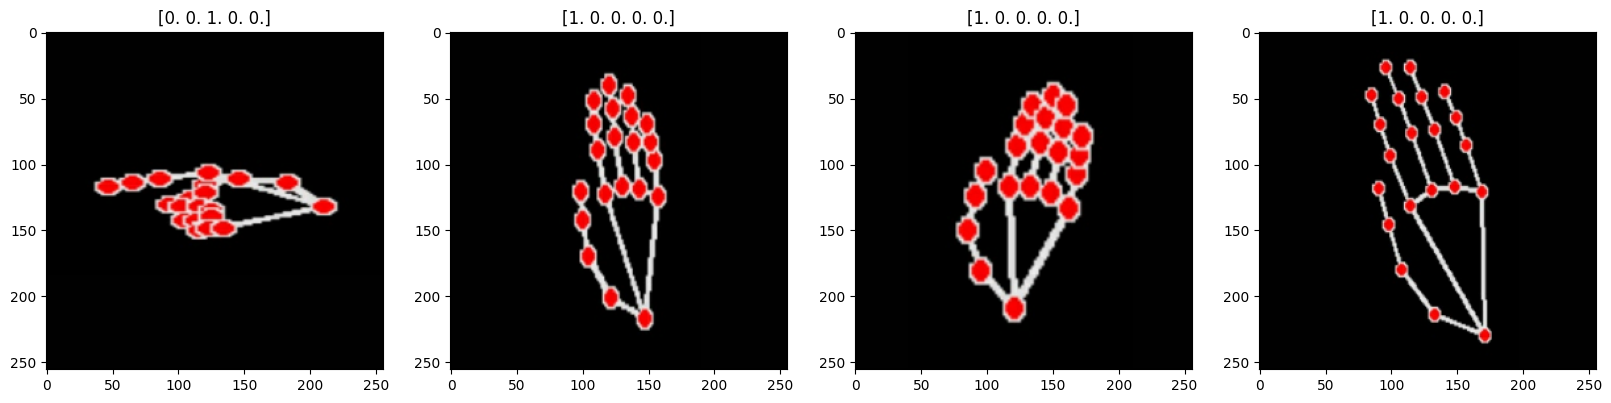

In [13]:
fig, axes = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    axes[idx].imshow(img.astype(int))
    axes[idx].title.set_text(batch[1][idx])

# 4. Scale Data

In [14]:
data = data.map(lambda x,y: (x/255, y))

In [15]:
data.as_numpy_iterator().next()

(array([[[[0.00392157, 0.00392157, 0.00392157],
          [0.00392157, 0.00392157, 0.00392157],
          [0.00392157, 0.00392157, 0.00392157],
          ...,
          [0.00392157, 0.00392157, 0.00392157],
          [0.00392157, 0.00392157, 0.00392157],
          [0.00392157, 0.00392157, 0.00392157]],
 
         [[0.00392157, 0.00392157, 0.00392157],
          [0.00392157, 0.00392157, 0.00392157],
          [0.00392157, 0.00392157, 0.00392157],
          ...,
          [0.00392157, 0.00392157, 0.00392157],
          [0.00392157, 0.00392157, 0.00392157],
          [0.00392157, 0.00392157, 0.00392157]],
 
         [[0.00392157, 0.00392157, 0.00392157],
          [0.00392157, 0.00392157, 0.00392157],
          [0.00392157, 0.00392157, 0.00392157],
          ...,
          [0.00392157, 0.00392157, 0.00392157],
          [0.00392157, 0.00392157, 0.00392157],
          [0.00392157, 0.00392157, 0.00392157]],
 
         ...,
 
         [[0.00392157, 0.00392157, 0.00392157],
          [0.00392

# 5. Split Data

In [29]:
train_size = int(len(data)*.8)
val_size = int(len(data)*.1)
test_size = int(len(data)*.1)

In [30]:
train_size

100

In [31]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

# 6. Build Deep Learning Model

In [32]:
train

<_TakeDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.float32, name=None))>

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.metrics import Precision, Recall, SparseCategoricalAccuracy

In [34]:
num_classes = 5
precision_metrics = [tf.keras.metrics.Precision(class_id=i) for i in range(num_classes)]
recall_metrics = [tf.keras.metrics.Recall(class_id=i) for i in range(num_classes)]

In [35]:
model = Sequential()

In [36]:
model.add(Conv2D(8, (3,3), activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(16, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(5, activation='softmax'))

In [37]:
model.compile(optimizer='adam', loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1, from_logits=False),
              metrics=['accuracy'] + precision_metrics + recall_metrics)

In [38]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 127, 127, 16)   │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 63, 63, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 30752)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │       984,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 990,293 (3.78 MB)

 Trainable params: 990,293 (3.78 MB)

 Non-trainable params: 0 (0.00 B)

# 7. Train

In [26]:
logdir='logs'

In [27]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [39]:
hist = model.fit(train, epochs=5, validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 205ms/step - accuracy: 0.7397 - loss: 0.9038 - precision_5: 0.8668 - precision_6: 0.9048 - precision_7: 0.8592 - precision_8: 0.9224 - precision_9: 0.8770 - recall_5: 0.5927 - recall_6: 0.7715 - recall_7: 0.4457 - recall_8: 0.5987 - recall_9: 0.5791 - val_accuracy: 0.9870 - val_loss: 0.4464 - val_precision_5: 0.9882 - val_precision_6: 1.0000 - val_precision_7: 1.0000 - val_precision_8: 1.0000 - val_precision_9: 0.9718 - val_recall_5: 1.0000 - val_recall_6: 0.9412 - val_recall_7: 1.0000 - val_recall_8: 1.0000 - val_recall_9: 0.9583
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 192ms/step - accuracy: 0.9577 - loss: 0.5737 - precision_5: 0.9917 - precision_6: 0.9909 - precision_7: 0.9945 - precision_8: 0.9857 - precision_9: 0.9929 - recall_5: 0.8919 - recall_6: 0.9083 - recall_7: 0.8683 - recall_8: 0.9109 - recall_9: 0.9367 - val_accuracy: 0.9974 - val_loss: 0.4177 - val_precision_5: 1.0000 - val_precision_6: 1.0000 - val_precision_7: 1.0000 - val_p

In [40]:
print(hist.history)

{'accuracy': [0.8687499761581421, 0.9665625095367432, 0.9743750095367432, 0.9800000190734863, 0.9856250286102295], 'loss': [0.7139546275138855, 0.5558701157569885, 0.5362662672996521, 0.5275818109512329, 0.5179954171180725], 'precision_5': [0.9468690752983093, 0.9947643876075745, 0.9965635538101196, 0.9949832558631897, 0.9983079433441162], 'precision_6': [0.9551166892051697, 0.9965217113494873, 1.0, 1.0, 1.0], 'precision_7': [0.9736263751983643, 0.9947826266288757, 0.9983221292495728, 1.0, 0.998344361782074], 'precision_8': [0.9802371263504028, 0.9885807633399963, 0.9967741966247559, 0.9966942071914673, 0.9967690110206604], 'precision_9': [0.9661017060279846, 0.9936000108718872, 0.9885807633399963, 0.9983686804771423, 1.0], 'recall_5': [0.7821316719055176, 0.9090909361839294, 0.9090909361839294, 0.9282371401786804, 0.9485530257225037], 'recall_6': [0.8539325594902039, 0.9212218523025513, 0.9241935610771179, 0.9371980428695679, 0.9567307829856873], 'recall_7': [0.6784073710441589, 0.889

In [59]:
model.trainable = False
for batch in test:
    features = batch[0]
    labels = batch[1]

    # Make predictions
    predictions = model.predict(features)
    

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


In [85]:
accuracy = tf.keras.metrics.Accuracy()
accuracy.update_state(predictions, labels)
accuracy_value = accuracy.result()
print(accuracy_value)

AttributeError: 'list' object has no attribute 'update_state'

# 8. Plot Performance

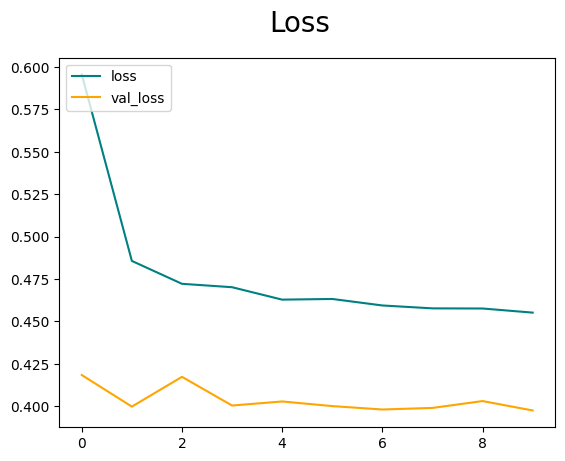

In [28]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

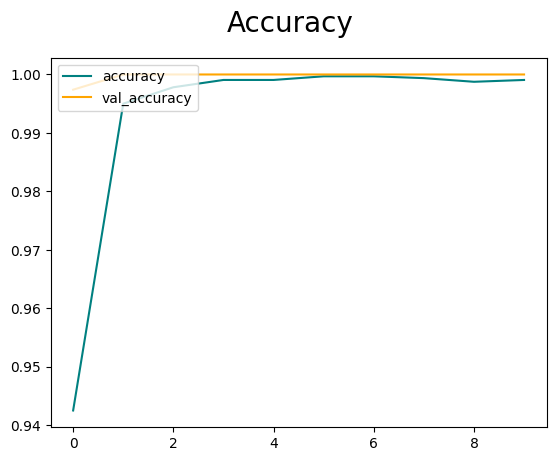

In [30]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

# 9. Evaluate

In [32]:
model_precision = Precision()
model_recall = Recall()
model_accuracy = SparseCategoricalAccuracy()

In [33]:
for batch in test.as_numpy_iterator(): 
    X, y = batch
    yhat = model.predict(X)
    model_precision.update_state(y, yhat)
    
    model_recall.update_state(y, yhat)
    model_accuracy.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step


InvalidArgumentError: {{function_node __wrapped__Equal_device_/job:localhost/replica:0/task:0/device:CPU:0}} Incompatible shapes: [32,5] vs. [32] [Op:Equal] name: 

In [136]:
print(model_precision.result(), model_recall.result(), model_accuracy.result())

tf.Tensor(1.0, shape=(), dtype=float32) tf.Tensor(1.0, shape=(), dtype=float32) tf.Tensor(0.0, shape=(), dtype=float32)


# 10. Test

In [185]:
import cv2

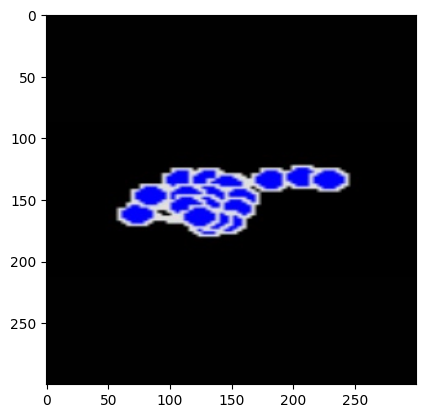

In [186]:
img = cv2.imread(os.path.join('data', 'right', 'image_1721672010.9853175.jpg'))
plt.imshow(img)
plt.show()

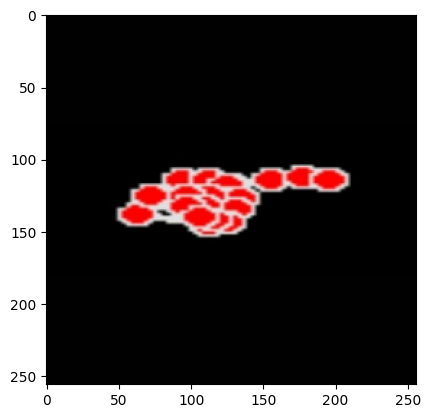

In [187]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = tf.image.resize(img_rgb, (256,256))
plt.imshow(img_resized.numpy().astype(int))
plt.show()

In [188]:
yhat = model.predict(np.expand_dims(img_resized/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


In [189]:
yhat

array([[0.01497921, 0.01369392, 0.01909395, 0.9378251 , 0.01440779]],
      dtype=float32)

In [ ]:
# if yhat > 0.5: 
#     print(f'Predicted class is Sad')
# else:
#     print(f'Predicted class is Happy')

# 11. Save the Model

In [190]:
from tensorflow.keras.models import load_model

In [191]:
model.save(os.path.join('model','presentation_keys.h5'))

In [192]:
new_model = load_model(os.path.join('model','presentation_keys.h5'))

In [145]:
new_model.predict(np.expand_dims(img_resized/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step


array([[0.02192114, 0.02144998, 0.01129606, 0.9273777 , 0.0179551 ]],
      dtype=float32)